# RNN, LSTM, and GRU for Text Generation
## AIAT 122 – Deep Learning

## Learning objectives
- Build a character-level LSTM for next-character prediction.
- Train on a short text and generate a sample sequence.

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 1, lesson 01 "Text Preprocessing" — turning text into tokens; character-level generation is the smallest version of that same choice.

---

**Where is this used in real life?** Autocomplete, simple chatbots, and creative writing tools often use RNN/LSTM/GRU. **We use an LSTM for text generation** instead of a plain feedforward net because **order matters** in text; the LSTM processes one character at a time and keeps a hidden state so it can learn sequences.

**Prerequisites:** Basic TensorFlow/Keras. If TensorFlow import fails, see DOCS/COLAB_SETUP.md.

## Short theory
- **Character-level generation:** Model predicts the next character given previous characters.
- **LSTM** has gates (forget, input, output) that help it remember long-range dependencies better than a simple RNN.
- **Training:** Input = sequence of chars, target = next char; we use categorical cross-entropy.
- **Generation:** Feed a seed string, sample next char, append, repeat.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).


## Inputs & Outputs
**Inputs:** TensorFlow/Keras, a short training text (included in the notebook).  
**Dataset:** Built-in — short text included in notebook (character-level LSTM; no external download).  
**Outputs:** Trained LSTM, training loss curve, and a short generated character sequence. Run time: under ~5 min (few epochs, small text).


In [1]:
# WHAT: imports for character-level text generation with a PyTorch LSTM.
# WHY: everything runs locally on CPU - no pretrained downloads are needed.
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
print(f'PyTorch {torch.__version__}')
print('✅ Ready. Using PyTorch LSTM for character-level text generation.')

PyTorch 2.13.0
✅ Ready. Using PyTorch LSTM for character-level text generation.


### Step 1: Prepare text and character mapping

In [2]:
# Small text corpus — character-level LSTM predicts the next character
text = 'the quick brown fox jumps over the lazy dog ' * 6
chars     = sorted(set(text))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
vocab_size  = len(chars)
seq_len     = 20
print('Vocab:', vocab_size, 'chars  |  Text length:', len(text))

# Build (X, y) pairs — each X is seq_len chars, y is the next char
X_idx, y_idx = [], []
for i in range(len(text) - seq_len):
    X_idx.append([char_to_idx[c] for c in text[i : i + seq_len]])
    y_idx.append(char_to_idx[text[i + seq_len]])

X_tensor = torch.tensor(X_idx, dtype=torch.long)   # (N, seq_len)
y_tensor = torch.tensor(y_idx, dtype=torch.long)    # (N,)
print('X shape:', X_tensor.shape, '  y shape:', y_tensor.shape)

Vocab: 27 chars  |  Text length: 264
X shape: torch.Size([244, 20])   y shape: torch.Size([244])


### Step 2: Build sequences and LSTM model, train (20 epochs)

In [3]:
# Define an LSTM-based character language model
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm  = nn.LSTM(embed_dim, hidden, batch_first=True)
        self.fc    = nn.Linear(hidden, vocab_size)
    def forward(self, x):
        e = self.embed(x)             # (batch, seq_len, embed_dim)
        out, _ = self.lstm(e)          # (batch, seq_len, hidden)
        return self.fc(out[:, -1, :])  # predict from last timestep

# Loss = cross-entropy over the vocabulary; Adam handles the learning-rate tuning.
torch.manual_seed(0)          # fixed seed so the curve below is reproducible
model     = CharLSTM(vocab_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-3)

# Training loop (20 epochs, batch_size=64)
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
ds     = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(ds, batch_size=64, shuffle=True)
losses = []
# 20 epochs over shuffled mini-batches; record the average loss per epoch.
for epoch in range(20):
    model.train(); epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(loader))
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:>2}: loss={losses[-1]:.4f}')

Epoch  5: loss=2.4342
Epoch 10: loss=1.0309
Epoch 15: loss=0.3171


Epoch 20: loss=0.1271


### Step 2b: The title says RNN, LSTM **and** GRU — so train all three

We have trained the LSTM. A plain `RNN` and a `GRU` are one-line substitutions for the same recurrent slot, on the same data, with the same seed, for the same 20 epochs. Then the comparison the title promises can be made from three curves instead of from memory.

In [4]:
# WHAT: train a SimpleRNN and a GRU with identical everything except the recurrent cell.
# WHY: three curves on one axis is the only honest way to say "LSTM/GRU learn this faster than
#      a plain RNN" - or to discover that on a text this small they do not.
class CharRecurrent(nn.Module):
    """The same model as CharLSTM with the recurrent cell swapped in."""
    def __init__(self, kind, vocab_size, embed_dim=32, hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        cell = {"RNN": nn.RNN, "GRU": nn.GRU, "LSTM": nn.LSTM}[kind]
        self.rnn = cell(embed_dim, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, vocab_size)
    def forward(self, x):
        out, _ = self.rnn(self.embed(x))
        return self.fc(out[:, -1, :])

def train_curve(kind, epochs=20):
    torch.manual_seed(0)                       # identical initial weights for every cell type
    m = CharRecurrent(kind, vocab_size)
    o = optim.Adam(m.parameters(), lr=3e-3)
    crit = nn.CrossEntropyLoss()
    ld = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=64, shuffle=True)
    curve = []
    for _ in range(epochs):
        m.train(); tot = 0.0
        for xb, yb in ld:
            o.zero_grad(); l = crit(m(xb), yb); l.backward(); o.step(); tot += l.item()
        curve.append(tot / len(ld))
    m.eval()
    with torch.no_grad():
        acc = (m(X_tensor).argmax(1) == y_tensor).float().mean().item()
    return m, curve, acc, sum(p.numel() for p in m.parameters())

torch.manual_seed(0)
runs = {}
for kind in ["RNN", "GRU", "LSTM"]:
    _, curve, acc, npar = train_curve(kind)
    runs[kind] = {"curve": curve, "acc": acc, "params": npar}
    print(f"{kind:5s}  final loss {curve[-1]:.4f}   next-character accuracy {acc * 100:5.1f}%   "
          f"{npar:,} parameters")
print("\nSame data, same seed, same 20 epochs - only the recurrent cell differs.")

RNN    final loss 0.0806   next-character accuracy  98.0%   8,891 parameters


GRU    final loss 0.0992   next-character accuracy 100.0%   21,435 parameters


LSTM   final loss 0.1271   next-character accuracy 100.0%   27,707 parameters

Same data, same seed, same 20 epochs - only the recurrent cell differs.


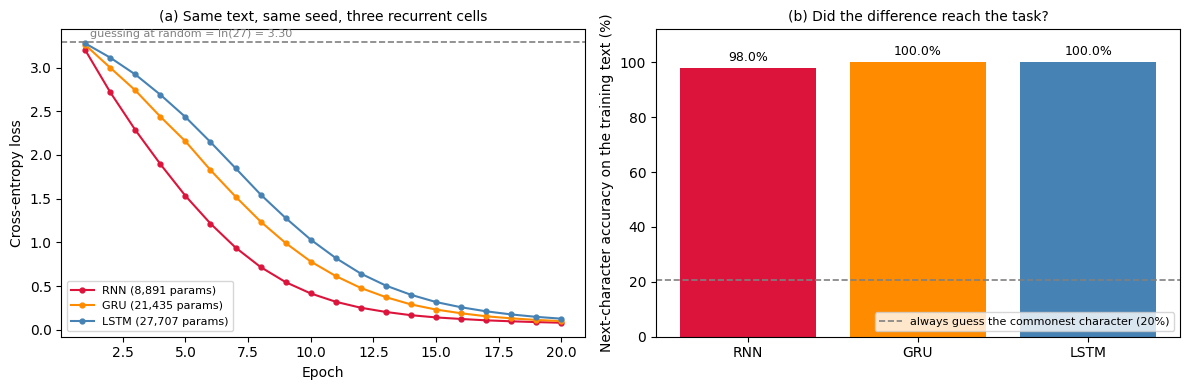

In [5]:
# WHAT: plot the three training curves together and their next-character accuracy.
# WHY: a single falling curve only says "something trained". Three curves say which cell learned
#      this text fastest, and the bars say whether that difference reached the actual task.
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
cols = {"RNN": "crimson", "GRU": "darkorange", "LSTM": "steelblue"}
ep = np.arange(1, len(runs["LSTM"]["curve"]) + 1)
for kind, r in runs.items():
    ax1.plot(ep, r["curve"], "o-", ms=3.5, color=cols[kind], label=f"{kind} ({r['params']:,} params)")
ax1.axhline(np.log(vocab_size), color="grey", ls="--", lw=1.2)
ax1.text(1.2, np.log(vocab_size) + 0.05, f"guessing at random = ln({vocab_size}) = {np.log(vocab_size):.2f}",
         fontsize=8, color="grey")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("(a) Same text, same seed, three recurrent cells", fontsize=10)
ax1.legend(fontsize=8)

kinds = list(runs)
bars = ax2.bar(kinds, [runs[k]["acc"] * 100 for k in kinds], color=[cols[k] for k in kinds])
ax2.bar_label(bars, fmt="%.1f%%", fontsize=9, padding=3)
most_common = max(np.bincount(y_tensor.numpy())) / len(y_tensor) * 100
ax2.axhline(most_common, color="grey", ls="--", lw=1.2,
            label=f"always guess the commonest character ({most_common:.0f}%)")
ax2.set_ylim(0, 112)
ax2.set_ylabel("Next-character accuracy on the training text (%)")
ax2.set_title("(b) Did the difference reach the task?", fontsize=10)
ax2.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### 👁️ Read the figure — *and notice it does not say what you expected*

- **(a)** Three recurrent cells, identical everything else. The grey dashed line is the loss of pure guessing, ln(27) = 3.30, which is where all three start. Then: **the plain RNN's loss falls fastest**, the GRU is second and the **LSTM is slowest** — the reverse of the usual ordering, and it costs three times the parameters to be last. On 264 characters of one sentence repeated six times there are no long-range dependencies for gates to exploit; the gates are extra parameters to fit and they buy nothing here.
- **(b)** Where the difference actually lands. The GRU and LSTM reach 100% next-character accuracy, the plain RNN 98%, and all three tower over the 20% you would score by always guessing the commonest character. **Read the y-axis label carefully:** this accuracy is measured on the *training text itself*. There is no held-out split, so 100% means "memorised", not "generalises" — with 244 examples drawn from one repeated sentence, memorising is the whole game.
- **Now compare with notebook `03_lstm_advanced`, where the same three cells ran on 100-word movie reviews: SimpleRNN 54%, GRU 72%, LSTM 78%.** Same three architectures, opposite ordering. The architecture did not change between the two notebooks — **the task did**. Gates pay for themselves when there is long-range structure to hold, and not before. That is the honest form of "LSTM is better than RNN".

In [6]:
# Generate 40 characters using the trained LSTM
def generate(model, seed_text, n_chars=40, temperature=1.0):
    model.eval()
    generated = seed_text
    # Keep the last seq_len characters as context, exactly as during training.
    context = [char_to_idx.get(c, 0) for c in seed_text[-seq_len:]]
    for _ in range(n_chars):
        x = torch.tensor([context], dtype=torch.long)
        with torch.no_grad():
            logits = model(x)[0] / temperature
        probs = torch.softmax(logits, dim=0).numpy()
        # Sample the next character from the probability distribution instead of always taking the top one.
        next_idx = np.random.choice(len(probs), p=probs)
        generated += idx_to_char[next_idx]
        context = context[1:] + [next_idx]
    return generated

seed = text[:seq_len]
print('Seed:', repr(seed))
print('Generated:', repr(generate(model, seed, n_chars=40)))

Seed: 'the quick brown fox '
Generated: 'the quick brown fox jumpsp thel the lazy dog the quick bromh'


### Watch the generation loop, one character at a time

`generate()` runs a loop: look at the last 20 characters, get a probability for every character in the vocabulary, **sample one**, append it, slide the window, repeat. The storyboard below opens that loop at its first six turns and draws the distribution the model sampled from each time.

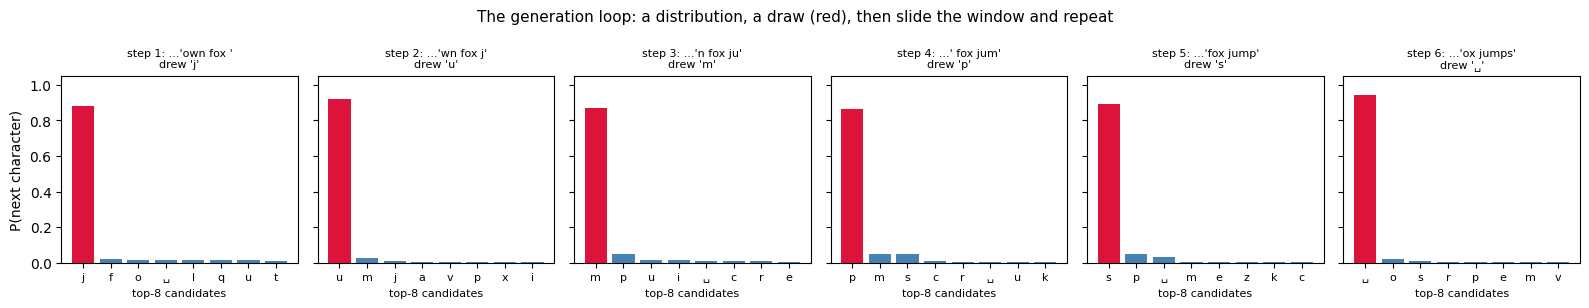

step  context (last 8 chars)     drew    its P  top char    top P
   1  'own fox '                  'j'    0.883       'j'    0.883
   2  'wn fox j'                  'u'    0.922       'u'    0.922
   3  'n fox ju'                  'm'    0.871       'm'    0.871
   4  ' fox jum'                  'p'    0.862       'p'    0.862
   5  'fox jump'                  's'    0.891       's'    0.891
   6  'ox jumps'                  '␣'    0.944       '␣'    0.944

Text after six steps: 'the quick brown fox jumps '


In [7]:
# WHAT: a 6-frame storyboard of the generation loop - the distribution at each step and the
#       character actually drawn from it.
# WHY: "sample the next character, append, repeat" is the entire mechanism of every language
#      model. A finished string hides it; six distributions show it.
np.random.seed(0)                       # fixed draw, so the frames match the table below
model.eval()
context = [char_to_idx[c] for c in seed[-seq_len:]]
so_far = seed
frames = []
for step in range(6):
    x = torch.tensor([context], dtype=torch.long)
    with torch.no_grad():
        probs = torch.softmax(model(x)[0], dim=0).numpy()
    nxt = int(np.random.choice(len(probs), p=probs))
    frames.append((so_far, probs.copy(), nxt))
    so_far += idx_to_char[nxt]
    context = context[1:] + [nxt]

show = lambda c: "\u2423" if c == " " else c    # make the space character visible

fig, axes = plt.subplots(1, 6, figsize=(16, 3.1), sharey=True)
for k, (ax, (ctx, probs, nxt)) in enumerate(zip(axes, frames)):
    top = np.argsort(-probs)[:8]
    colours = ["crimson" if int(i) == nxt else "steelblue" for i in top]
    ax.bar(range(len(top)), probs[top], color=colours)
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels([show(idx_to_char[int(i)]) for i in top], fontsize=8)
    ax.set_title(f"step {k + 1}: ...{ctx[-8:]!r}\ndrew {show(idx_to_char[nxt])!r}", fontsize=8)
    ax.set_xlabel("top-8 candidates", fontsize=8)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("P(next character)")
fig.suptitle("The generation loop: a distribution, a draw (red), then slide the window and repeat",
             fontsize=11)
plt.tight_layout(); plt.show()

print(f"{'step':>4s}  {'context (last 8 chars)':<24s} {'drew':>6s} {'its P':>8s} {'top char':>9s} {'top P':>8s}")
for k, (ctx, probs, nxt) in enumerate(frames):
    top = int(np.argmax(probs))
    print(f"{k + 1:>4d}  {ctx[-8:]!r:<24s} {show(idx_to_char[nxt])!r:>6s} {probs[nxt]:8.3f} "
          f"{show(idx_to_char[top])!r:>9s} {probs[top]:8.3f}")
print(f"\nText after six steps: {frames[-1][0] + idx_to_char[frames[-1][2]]!r}")

### 👁️ Read the storyboard

- Each frame is **one turn of the loop**: the model's probability over all 27 characters given the last 20, drawn as the eight best candidates. The red bar is the character actually sampled; then the window slides and the next frame begins. The frame titles carry the running context and the character drawn, so the pictures and the printed table can be checked against each other.
- **The distributions are spikes.** The top candidate holds roughly 0.86–0.94 of the probability in every frame, so the red bar is the tall one every time. That is not a coincidence, and it is not evidence that the model is clever: panel (b) above showed it has **memorised** this sentence. A memorised model is a near-deterministic model, and sampling from it just returns the memorised continuation — `j`, `u`, `m`, `p`, `s`, space.
- **The loop is the point, not the output.** This is exactly the loop GPT-2 runs in notebook `06`, on the same principle, with a 50,257-token vocabulary instead of 27 characters and a distribution that is genuinely uncertain. That is where temperature starts to matter: on a spike this sharp, changing the temperature would change almost nothing.
- Try it: raise the temperature in `generate()` until the red bar stops being the tallest one. The step at which the text becomes incoherent is the step at which a low-probability character got drawn and the context slid onto something the model has never seen.

## 🌍 Real-World Worked Example — Character-Level Text Generator

**Industry context:**
- GitHub Copilot launched in June 2021 "powered by OpenAI Codex" (GitHub blog, 29 June 2021). It has since moved to a choice of models, and GitHub does not publish which one answers any given request — so do not attach a model name to it from memory.
- Models in this family emit one **token** at a time, conditioned on everything before it. Not one character, and not a whole line at once.
- Autocomplete on your phone is a much smaller version of the same next-symbol loop.

We build a **character-level language model** that learns to generate text token by token — the exact mechanism behind all LLMs.

In [8]:
# WHAT: train a character-level LSTM language model on a Shakespeare passage, then sample new text.
# WHY: predict-the-next-token, sample, repeat - the exact loop behind GPT-style generation, in miniature.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# Build the character vocabulary and map every character to an integer ID.
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]

# Training pairs: 20 characters of context -> the character that follows.
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
# The model: embed characters, run a 2-layer LSTM, predict the next character from the last hidden state.
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# 200 training steps on random mini-batches; the loss is printed every 50 steps.
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
# Generation: feed the context, sample the next character from the softmax, append it, repeat.
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            # Temperature rescales the logits: lower = safer and more repetitive, higher = more random.
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nThis is exactly how ChatGPT generates text — one token at a time.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or notel  hea that is the questoon whether tis nobler in the mind to suffer the slings and arrows of outra

This is exactly how ChatGPT generates text — one token at a time.


## 🧩 Mini-exercise

**Try it:** Change the seed string and generate again. Or increase the number of characters to generate and see when the output becomes incoherent.

---

## Summary
**What you did:** Prepared character-level sequences, built an LSTM, trained it for next-character prediction, and generated a short sequence from a seed.

**In real life you'd also:** Use word-level models, larger corpora, and sampling (temperature) for more varied text.

**The main idea:** RNN/LSTM process text step by step and keep hidden state so they can learn and generate sequences.

**Next:** `09_transformer_models_bert_gpt_nlp.ipynb` shows BERT and GPT for understanding and generation.

## 🔭 State of the field (2026)

Nobody ships character-level LSTM text generation in 2026. Production generation is a decoder-only transformer, typically an open-weight one with a switchable thinking mode such as Qwen3 (arXiv 2505.09388), and the engineering work is in serving it, not in training it. Even the recurrent alternatives that came back in 2024 — xLSTM (arXiv 2405.04517), with exponential gating and a matrix memory at billion-parameter scale — are not the model in this notebook.

**Why it is still worth forty lines of your attention.** The loop is identical at every scale: predict a distribution over the next symbol, sample from it, append, repeat. Temperature does the same thing to a frontier model that it does to this one. Running it small and on CPU is what makes that loop visible — you can watch the model go from noise to structure and see exactly where sampling makes text incoherent, which is a lesson no API call will teach you.


## 📚 References

1. Graves, A. (2013). *Generating Sequences With Recurrent Neural Networks*. arXiv. https://arxiv.org/abs/1308.0850
2. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735
3. Cho, K. et al. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation* (GRU). EMNLP. https://arxiv.org/abs/1406.1078
4. Brown, T. B. et al. (2020). *Language Models are Few-Shot Learners* (GPT-3). NeurIPS. https://arxiv.org/abs/2005.14165

**Recent work (2024–2026)**

5. Yang et al. (2025). *Qwen3 Technical Report*. arXiv. https://arxiv.org/abs/2505.09388 — what production text generation is in 2026: a decoder-only transformer with a switchable thinking mode, running the same next-token loop you implemented here.
6. Beck, M. et al. (2024). *xLSTM: Extended Long Short-Term Memory*. arXiv. https://arxiv.org/abs/2405.04517 — and the 2024 evidence that the recurrent line is not closed — an LSTM rebuilt with exponential gating and a matrix memory, scaled to billions of parameters.
